# EDA: Retail, Churn, and Event Data

Стартовый ноутбук для первичного анализа кейса Ростелеком. Он помогает быстро понять структуру данных, проверить их качество и собрать гипотезы для трех будущих контуров решения:

- аналитика и BI;
- прогнозирование оттока;
- рекомендательная система.

Ноутбук рассчитан на большие CSV, поэтому в тяжелых местах используется агрегация, а не полное рисование всего подряд.

## План анализа

1. Загрузить данные и привести типы.
2. Проверить размер, состав колонок и качество данных.
3. Посмотреть базовую динамику заказов и событий.
4. Оценить поведение клиентов, возвраты и логистику.
5. Зафиксировать гипотезы для feature engineering, churn и recsys.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 200)
sns.set_theme(style="whitegrid", context="talk")

BASE_DIR = Path("..")
DATA_PATH = BASE_DIR / "data.csv"
EVENTS_PATH = BASE_DIR / "events.csv"


In [2]:
def parse_datetime_columns(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    df = df.copy()
    for col in columns:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], utc=True, errors="coerce", format="mixed")
    return df


def missing_report(df: pd.DataFrame, top_n: int = 20) -> pd.DataFrame:
    report = (
        df.isna()
        .mean()
        .sort_values(ascending=False)
        .rename("missing_share")
        .to_frame()
    )
    report["missing_pct"] = (report["missing_share"] * 100).round(2)
    return report.head(top_n)


def plot_top_categories(series: pd.Series, title: str, top_n: int = 10, figsize=(12, 6)):
    values = series.astype("string").fillna("<NA>").value_counts().head(top_n).sort_values()
    ax = values.plot(kind="barh", figsize=figsize, color="#2f6db3")
    ax.set_title(title)
    ax.set_xlabel("Count")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()


In [3]:
data = pd.read_csv(DATA_PATH)
events = pd.read_csv(EVENTS_PATH)

data = parse_datetime_columns(
    data,
    ["created_at", "returned_at", "shipped_at", "delivered_at", "sold_at"],
)
events = parse_datetime_columns(events, ["created_at"])

data.shape, events.shape


((545778, 49), (4865324, 13))

## 1. Обзор датасетов

`data.csv` похож на широкий денормализованный слой: заказы, пользователи, товарные атрибуты, логистика, лояльность и текстовые отзывы. `events.csv` содержит цифровой след пользователя: сессии, источники трафика, URI и типы событий.

In [4]:
summary = pd.DataFrame(
    {
        "rows": [len(data), len(events)],
        "columns": [data.shape[1], events.shape[1]],
        "memory_mb": [round(data.memory_usage(deep=True).sum() / 1024**2, 1), round(events.memory_usage(deep=True).sum() / 1024**2, 1)],
        "time_min": [data["created_at"].min(), events["created_at"].min()],
        "time_max": [data["created_at"].max(), events["created_at"].max()],
    },
    index=["data", "events"],
)
summary


,rows,columns,memory_mb,time_min,time_max
data,545778,49,998.4,2019-01-04 03:52:40+00:00,2026-03-11 00:47:27+00:00
events,4865324,13,2730.4,2019-01-02 00:28:00+00:00,2026-03-14 23:47:14.428164+00:00


In [5]:
display(data.head(2))
display(events.head(2))


,order_id,user_id,status,gender,created_at,returned_at,shipped_at,delivered_at,num_of_item,product_id,inventory_item_id,sale_price,id,first_name,last_name,email,age,state,street_address,postal_code,city,country,traffic_source,user_geom,cost,category,brand,retail_price,department,sku,distribution_center_id,sold_at,product_category,product_name,product_brand,product_retail_price,product_department,product_sku,product_distribution_center_id,distribution_center_geom,order_item_id,delivery_longitude,delivery_latitude,warehouse_name,warehouse_longitude,warehouse_latitude,is_loyal,product_name_clean,customer_review
0,118730,94911,Shipped,F,2026-03-11 00:47:27+00:00,NaT,2026-03-12 20:06:27+00:00,NaT,1,2200,467205,32.990002,94911,Kelly,Glenn,kellyglenn@example.net,43,Arkansas,625 Dominique Crest,71603,Pine Bluff,United States,Email,POINT(-92.0886782 34.12795471),16.330051,Fashion Hoodies & Sweatshirts,Activewear Apparel,32.990002,Women,5249EE8E0CFF02AD6B4CC0EE0E50B7D1,1,NaT,Fashion Hoodies & Sweatshirts,Bella Two-Tone Full-Zip Hooded Sweatshirt,Activewear Apparel,32.990002,Women,5249EE8E0CFF02AD6B4CC0EE0E50B7D1,1,POINT(-89.9711 35.1174),172697,-92.088678,34.127955,Memphis TN,-89.9711,35.1174,False,Bella Two-Tone Full-Zip Hooded Sweatshirt,Just received the Bella Two-Tone Full-Zip Hood...
1,114939,91961,Shipped,M,2026-03-11 00:46:02+00:00,NaT,2026-03-13 23:10:02+00:00,NaT,2,21920,452206,39.570000,91961,Samuel,Blankenship,samuelblankenship@example.net,18,California,179 Robinson Path Apt. 573,93662,Selma,United States,Search,POINT(-119.6458146 36.53499187),19.824570,Pants,Calvin Klein,39.570000,Men,DFE8DF8FC9712F0825E6C949470567B7,3,NaT,Pants,Calvin Klein Sportswear Men's Broken Micro Che...,Calvin Klein,39.570000,Men,DFE8DF8FC9712F0825E6C949470567B7,3,POINT(-95.3698 29.7604),167157,-119.645815,36.534992,Houston TX,-95.3698,29.7604,False,Calvin Klein Sportswear Men's Broken Micro Che...,I really liked this Calvin Klein Sportswear Me...


,id,user_id,sequence_number,session_id,created_at,ip_address,city,state,postal_code,browser,traffic_source,uri,event_type
0,1840721,NaN,3,32c825f3-2e85-4f79-ad2b-188d3ae22785,2022-12-27 02:05:00+00:00,153.11.214.106,São Paulo,São Paulo,02675-031,Chrome,Email,/cancel,cancel
1,1677966,NaN,3,1e21f050-a916-4863-94a0-2a4e474d60c2,2024-06-30 16:04:00+00:00,62.51.52.204,São Paulo,São Paulo,02675-031,Firefox,Adwords,/cancel,cancel


## 2. Качество данных

Сначала проверяем пропуски, дубликаты и аномалии типов. Это поможет заранее понять, где будут риски для обучения моделей и построения витрин.

In [6]:
display(missing_report(data, top_n=20))
display(missing_report(events, top_n=15))


,missing_share,missing_pct
sold_at,1.000000,100.00
returned_at,0.900740,90.07
delivered_at,0.651644,65.16
shipped_at,0.351286,35.13
city,0.009993,1.00
brand,0.001011,0.10
product_brand,0.001011,0.10
product_name_clean,0.000038,0.00
product_name,0.000038,0.00
product_department,0.000000,0.00


,missing_share,missing_pct
user_id,0.462146,46.21
city,0.009892,0.99
id,0.000000,0.00
sequence_number,0.000000,0.00
session_id,0.000000,0.00
created_at,0.000000,0.00
ip_address,0.000000,0.00
state,0.000000,0.00
postal_code,0.000000,0.00
browser,0.000000,0.00


In [7]:
duplicate_checks = pd.Series(
    {
        "data_full_duplicates": data.duplicated().sum(),
        "events_full_duplicates": events.duplicated().sum(),
        "duplicate_order_item_id": data["order_item_id"].duplicated().sum(),
        "duplicate_event_id": events["id"].duplicated().sum(),
    }
).to_frame("count")
duplicate_checks


,count
data_full_duplicates,363852
events_full_duplicates,2432662
duplicate_order_item_id,363852
duplicate_event_id,2432662


In [8]:
# Важный бизнес-контекст: некоторые пропуски могут быть не ошибками, а отражать статус заказа.
status_nulls = (
    data.groupby("status")[["returned_at", "shipped_at", "delivered_at"]]
    .apply(lambda frame: frame.isna().mean().round(3))
)
status_nulls


,returned_at,shipped_at,delivered_at
status,,,
Cancelled,1.0,1.0,1.0
Complete,1.0,0.0,0.0
Processing,1.0,1.0,1.0
Returned,0.0,0.0,0.0
Shipped,1.0,0.0,1.0


## 3. Транзакции и выручка

Здесь формируем первый взгляд на бизнес-динамику: сколько заказов, как ведет себя выручка, какие категории и каналы доминируют.

In [9]:
orders = (
    data.groupby("order_id", as_index=False)
    .agg(
        user_id=("user_id", "first"),
        created_at=("created_at", "min"),
        status=("status", "first"),
        items_cnt=("order_item_id", "nunique"),
        revenue=("sale_price", "sum"),
        is_loyal=("is_loyal", "max"),
    )
)
orders["month"] = orders["created_at"].dt.tz_localize(None).dt.to_period("M").astype(str)
orders.head()


,order_id,user_id,created_at,status,items_cnt,revenue,is_loyal,month
0,1,1,2024-10-14 10:31:40+00:00,Complete,1,166.470005,False,2024-10
1,2,2,2025-04-11 13:43:06+00:00,Complete,2,372.000000,True,2025-04
2,3,2,2020-06-24 23:00:38+00:00,Cancelled,2,142.500000,True,2020-06
3,4,3,2022-09-05 21:23:16+00:00,Returned,2,155.969999,False,2022-09
4,5,4,2026-02-28 07:34:44+00:00,Shipped,1,67.500000,False,2026-02


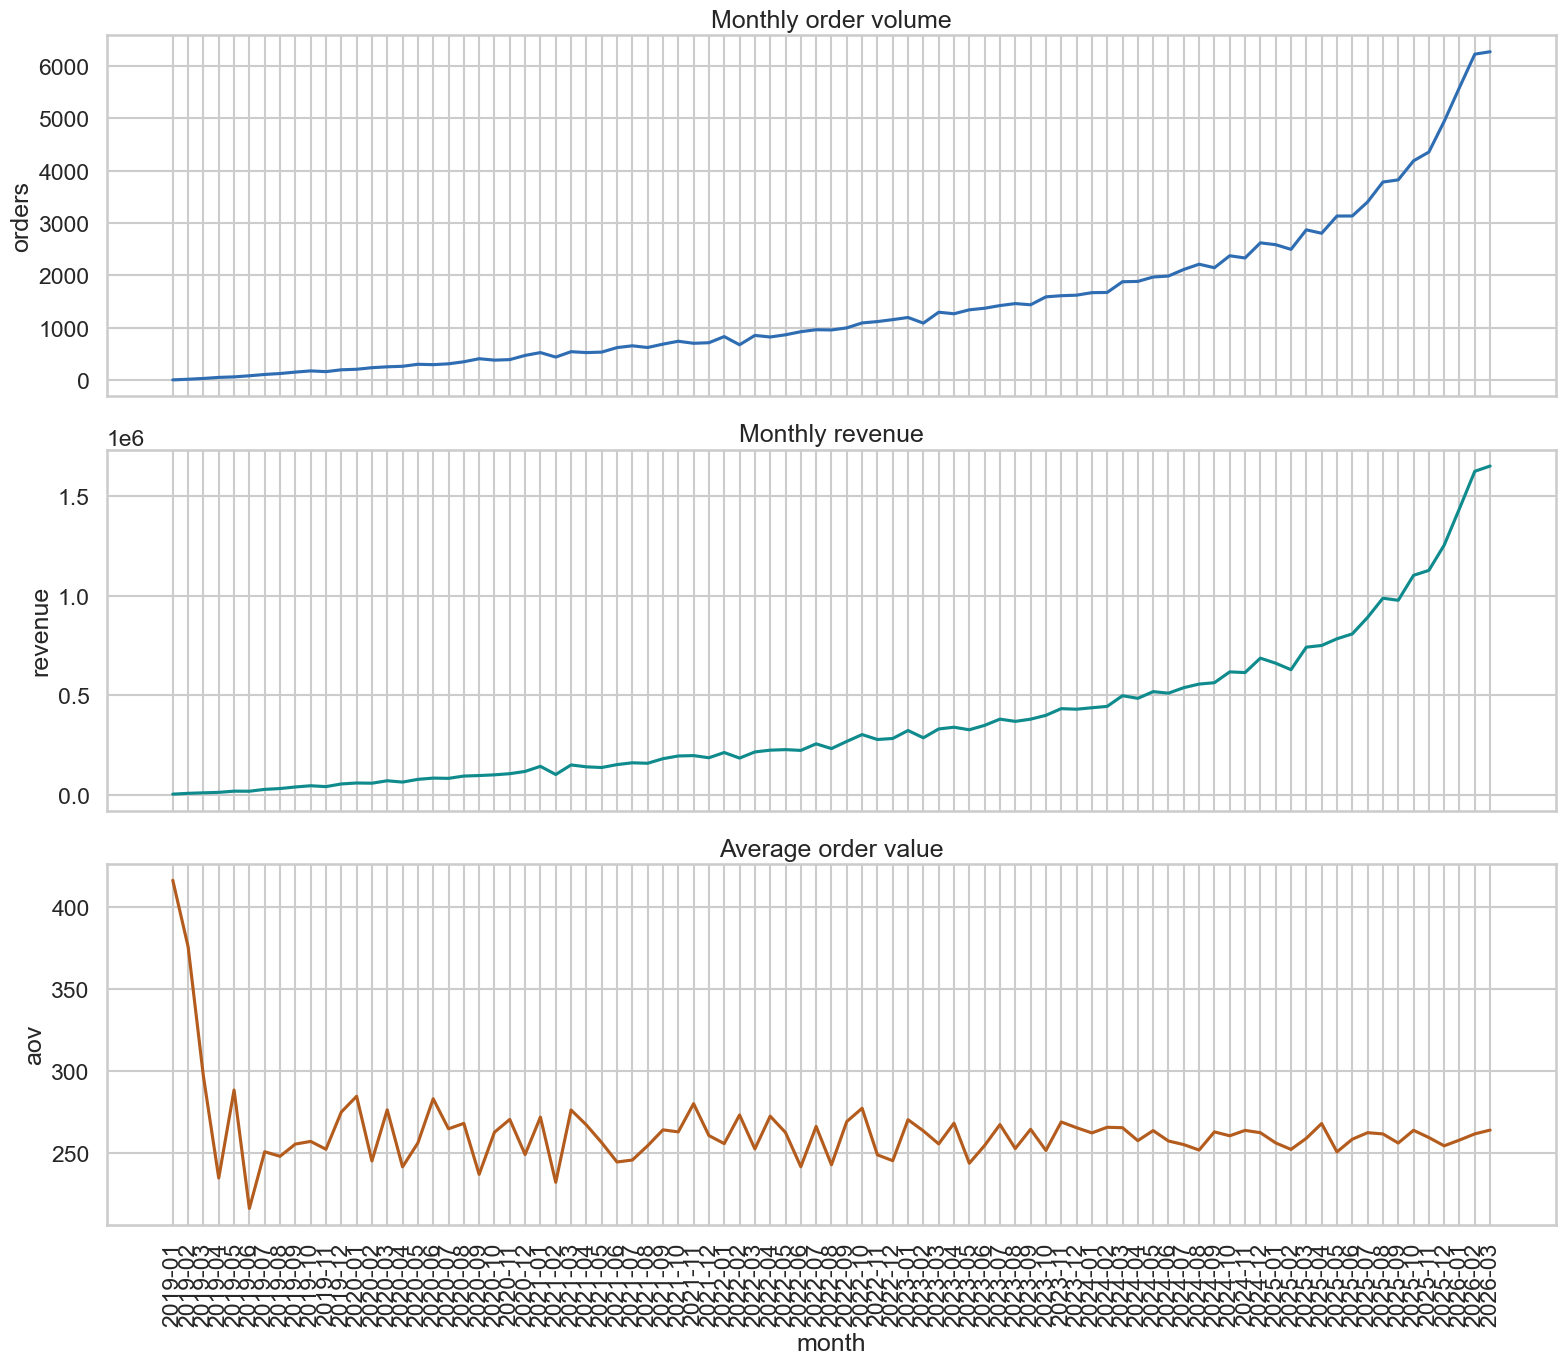

In [10]:
monthly = orders.groupby("month", as_index=False).agg(
    orders=("order_id", "nunique"),
    revenue=("revenue", "sum"),
    aov=("revenue", "mean"),
)

fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)
sns.lineplot(data=monthly, x="month", y="orders", ax=axes[0], color="#2f6db3")
sns.lineplot(data=monthly, x="month", y="revenue", ax=axes[1], color="#0f8b8d")
sns.lineplot(data=monthly, x="month", y="aov", ax=axes[2], color="#b35c1e")
axes[0].set_title("Monthly order volume")
axes[1].set_title("Monthly revenue")
axes[2].set_title("Average order value")
for ax in axes:
    ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()


,share_pct
status,
Shipped,29.95
Complete,24.90
Processing,20.05
Cancelled,15.10
Returned,9.99


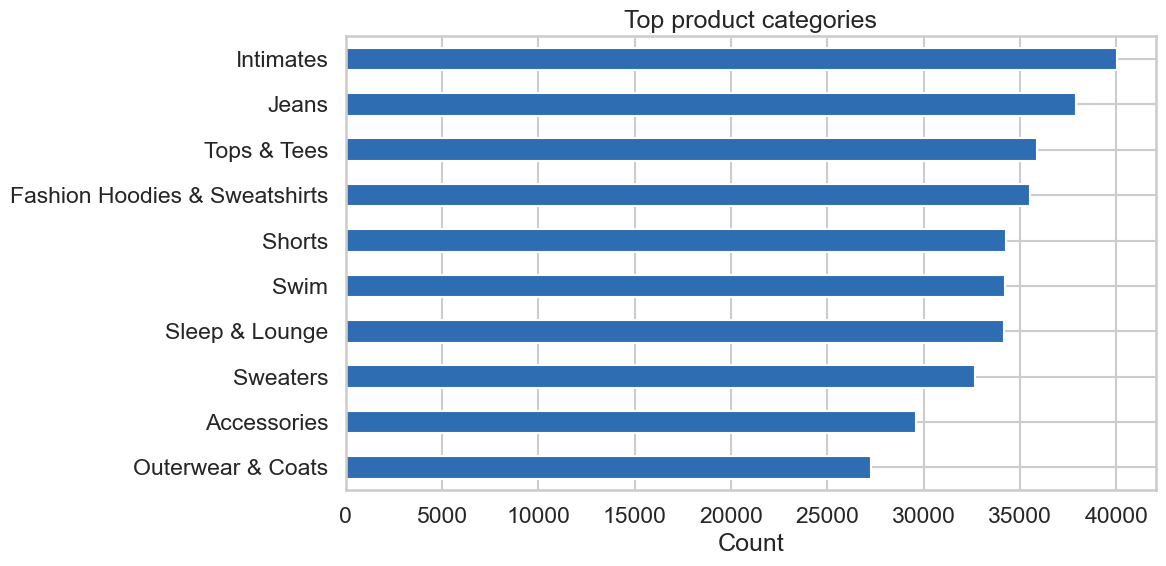

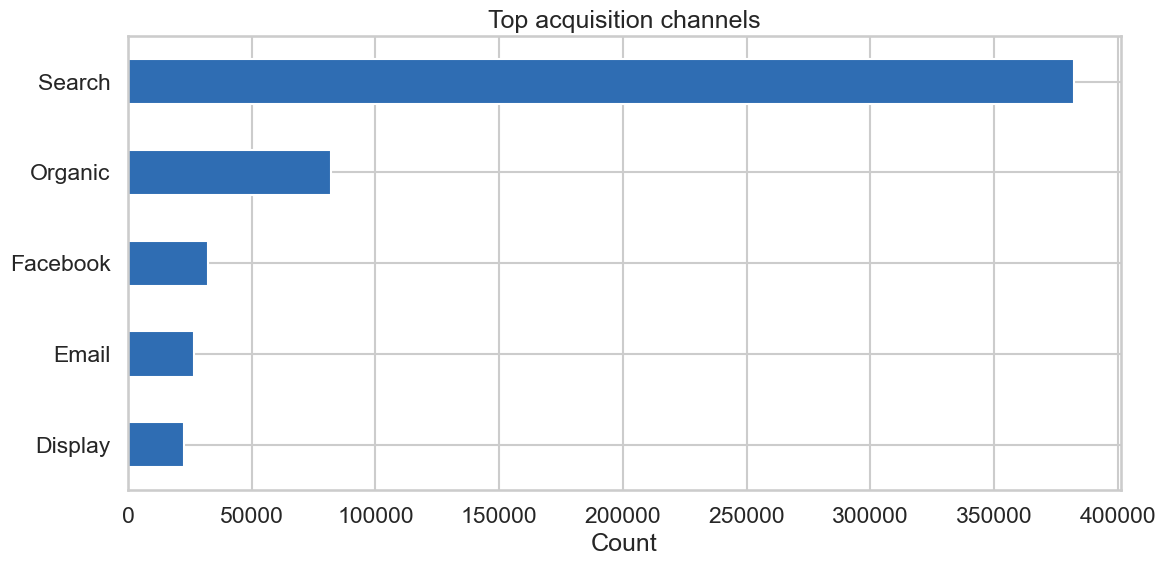

In [11]:
display((orders["status"].value_counts(normalize=True) * 100).round(2).rename("share_pct").to_frame())
plot_top_categories(data["category"], "Top product categories")
plot_top_categories(data["traffic_source"], "Top acquisition channels")


## 4. Клиенты и первые churn-сигналы

На этом этапе нам важны частота покупок, распределение выручки на клиента, признаки лояльности и первые кандидаты в churn features.

In [12]:
customer_mart = (
    orders.groupby("user_id", as_index=False)
    .agg(
        orders_cnt=("order_id", "nunique"),
        total_revenue=("revenue", "sum"),
        avg_order_value=("revenue", "mean"),
        first_order_at=("created_at", "min"),
        last_order_at=("created_at", "max"),
        loyal_flag=("is_loyal", "max"),
    )
)
customer_mart["customer_lifetime_days"] = (customer_mart["last_order_at"] - customer_mart["first_order_at"]).dt.days
customer_mart.describe(include="all").T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
user_id,80021.0,NaN,NaN,NaN,49986.382062,1.0,25022.0,50027.0,75056.0,99999.0,28874.949698
orders_cnt,80021.0,NaN,NaN,NaN,1.563152,1.0,1.0,1.0,2.0,4.0,0.865932
total_revenue,80021.0,NaN,NaN,NaN,405.760069,0.06,123.899998,268.5,545.940022,6433.199993,416.58412
avg_order_value,80021.0,NaN,NaN,NaN,259.031304,0.06,104.970005,187.080002,330.239995,4028.850002,246.073867
first_order_at,80021,NaN,NaN,NaN,2024-03-03 04:26:50.912315904+00:00,2019-01-04 03:52:40+00:00,2023-01-18 02:21:15+00:00,2024-07-31 13:33:40+00:00,2025-08-11 01:30:04+00:00,2026-03-11 00:47:27+00:00,NaN
last_order_at,80021,NaN,NaN,NaN,2024-09-14 09:27:20.999555584+00:00,2019-01-04 03:52:40+00:00,2023-12-09 12:53:50+00:00,2025-03-13 14:21:37+00:00,2025-11-15 03:50:47+00:00,2026-03-11 00:47:27+00:00,NaN
loyal_flag,80021,2,False,64491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_lifetime_days,80021.0,NaN,NaN,NaN,195.021932,0.0,0.0,0.0,190.0,2552.0,392.782586


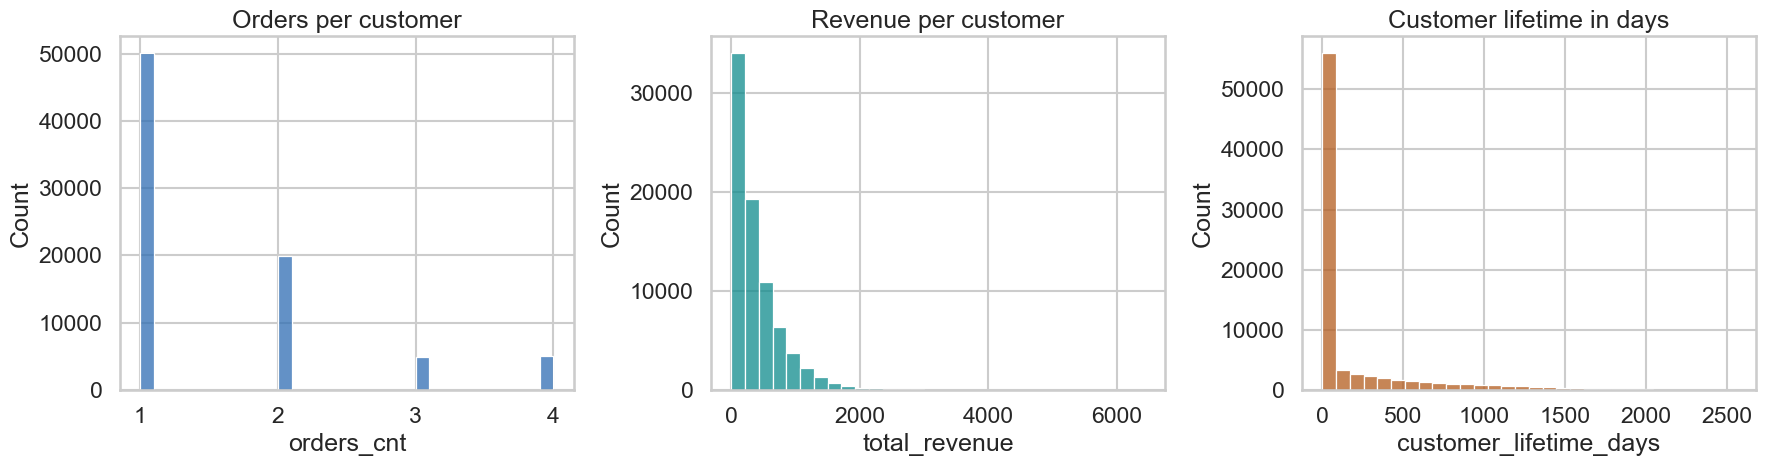

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(customer_mart["orders_cnt"], bins=30, ax=axes[0], color="#2f6db3")
sns.histplot(customer_mart["total_revenue"], bins=30, ax=axes[1], color="#0f8b8d")
sns.histplot(customer_mart["customer_lifetime_days"], bins=30, ax=axes[2], color="#b35c1e")
axes[0].set_title("Orders per customer")
axes[1].set_title("Revenue per customer")
axes[2].set_title("Customer lifetime in days")
plt.tight_layout()
plt.show()


In [14]:
customer_mart.groupby("loyal_flag")[["orders_cnt", "total_revenue", "avg_order_value", "customer_lifetime_days"]].median()


,orders_cnt,total_revenue,avg_order_value,customer_lifetime_days
loyal_flag,,,,
False,1.0,203.940004,160.830003,0.0
True,3.0,785.940010,319.665004,346.0


## 5. Логистика, возвраты и качество товара

Это очень важный блок для будущего churn. Проверяем, как сроки доставки и возвраты связаны со статусами, складами и категориями.

In [15]:
delivery = data.copy()
delivery["ship_delay_days"] = (delivery["shipped_at"] - delivery["created_at"]).dt.total_seconds() / 86400
delivery["delivery_days"] = (delivery["delivered_at"] - delivery["shipped_at"]).dt.total_seconds() / 86400
delivery["return_days"] = (delivery["returned_at"] - delivery["delivered_at"]).dt.total_seconds() / 86400

delivery[["ship_delay_days", "delivery_days", "return_days"]].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])


,ship_delay_days,delivery_days,return_days
count,354054.000000,190125.000000,54174.000000
mean,1.497028,2.504978,1.493445
std,0.867428,1.443456,0.863805
min,0.000000,0.000000,0.000000
25%,0.747917,1.261111,0.754167
50%,1.494444,2.501389,1.481250
75%,2.246528,3.768056,2.240278
90%,2.700000,4.500000,2.694444
95%,2.852083,4.749167,2.845382
99%,2.970833,4.947917,2.963194


In [16]:
warehouse_perf = (
    delivery.groupby("warehouse_name", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        median_delivery_days=("delivery_days", "median"),
        return_rate=("returned_at", lambda x: x.notna().mean()),
    )
    .sort_values(["orders", "median_delivery_days"], ascending=[False, False])
)
warehouse_perf.head(15)


,warehouse_name,orders,median_delivery_days,return_rate
1,Chicago IL,22830,2.465972,0.097577
4,Memphis TN,22757,2.550000,0.099425
2,Houston TX,21584,2.447917,0.097862
5,Mobile AL,17562,2.501389,0.099755
3,Los Angeles CA,16706,2.480556,0.100503
0,Charleston SC,16153,2.501042,0.100125
7,Philadelphia PA,15999,2.509375,0.095044
8,Port Authority of New York/New Jersey NY/NJ,15774,2.504167,0.100304
6,New Orleans LA,12551,2.550000,0.104216
9,Savannah GA,11570,2.525000,0.100277


In [17]:
category_returns = (
    delivery.groupby(["department", "category"], as_index=False)
    .agg(
        order_items=("order_item_id", "nunique"),
        return_rate=("returned_at", lambda x: x.notna().mean()),
        avg_price=("sale_price", "mean"),
    )
    .query("order_items >= 100")
    .sort_values("return_rate", ascending=False)
)
category_returns.head(20)


,department,category,order_items,return_rate,avg_price
22,Women,Jumpsuits & Rompers,913,0.113910,44.979409
26,Women,Pants & Capris,3478,0.110121,55.871590
11,Men,Swim,6373,0.106857,49.811243
31,Women,Socks & Hosiery,3765,0.106507,16.740669
9,Men,Suits & Sport Coats,5200,0.105000,127.131259
30,Women,Sleep & Lounge,4735,0.104329,47.451510
13,Men,Underwear,7651,0.103254,27.154112
7,Men,Sleep & Lounge,6648,0.103189,49.908770
16,Women,Blazers & Jackets,3284,0.101705,92.090926
34,Women,Swim,5030,0.101392,65.473557


## 6. Поведенческие события

Событийный поток нужен не только для витрин, но и для поведенческих признаков: глубина сессии, путь до покупки, частота отмен, интерес к категориям и маркетинговым каналам.

In [18]:
session_mart = (
    events.groupby("session_id", as_index=False)
    .agg(
        user_id=("user_id", "max"),
        session_start=("created_at", "min"),
        session_end=("created_at", "max"),
        events_cnt=("id", "count"),
        max_sequence=("sequence_number", "max"),
        traffic_source=("traffic_source", "first"),
        browser=("browser", "first"),
    )
)
session_mart["session_duration_min"] = (
    session_mart["session_end"] - session_mart["session_start"]
).dt.total_seconds() / 60
session_mart.describe(include="all").T.head(20)


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
session_id,681926,681926,00001739-0da6-47b4-99c2-4b7b34a9bb2c,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
user_id,181926.0,NaN,NaN,NaN,49966.400201,1.0,25032.5,49934.5,75030.0,99999.0,28880.508717
session_start,681926,NaN,NaN,NaN,2023-01-31 20:53:45.405690368+00:00,2019-01-02 00:28:00+00:00,2021-04-20 17:20:15+00:00,2023-04-20 09:11:25.500000+00:00,2024-12-27 05:17:13.249999872+00:00,2026-03-11 00:23:08.651687+00:00,NaN
session_end,681926,NaN,NaN,NaN,2023-02-01 03:48:03.417662720+00:00,2019-01-02 00:28:00+00:00,2021-04-21 00:58:45+00:00,2023-04-20 13:51:40+00:00,2024-12-27 14:23:29.500000+00:00,2026-03-14 23:47:14.428164+00:00,NaN
events_cnt,681926.0,NaN,NaN,NaN,7.13468,2.0,4.0,6.0,10.0,26.0,5.432452
max_sequence,681926.0,NaN,NaN,NaN,3.56734,1.0,2.0,3.0,5.0,13.0,2.716226
traffic_source,681926,5,Email,306711,NaN,NaN,NaN,NaN,NaN,NaN,NaN
browser,681926,5,Chrome,341701,NaN,NaN,NaN,NaN,NaN,NaN,NaN
session_duration_min,681926.0,NaN,NaN,NaN,414.3002,0.0,4.616667,16.383333,33.0,5789.116667,1249.192706


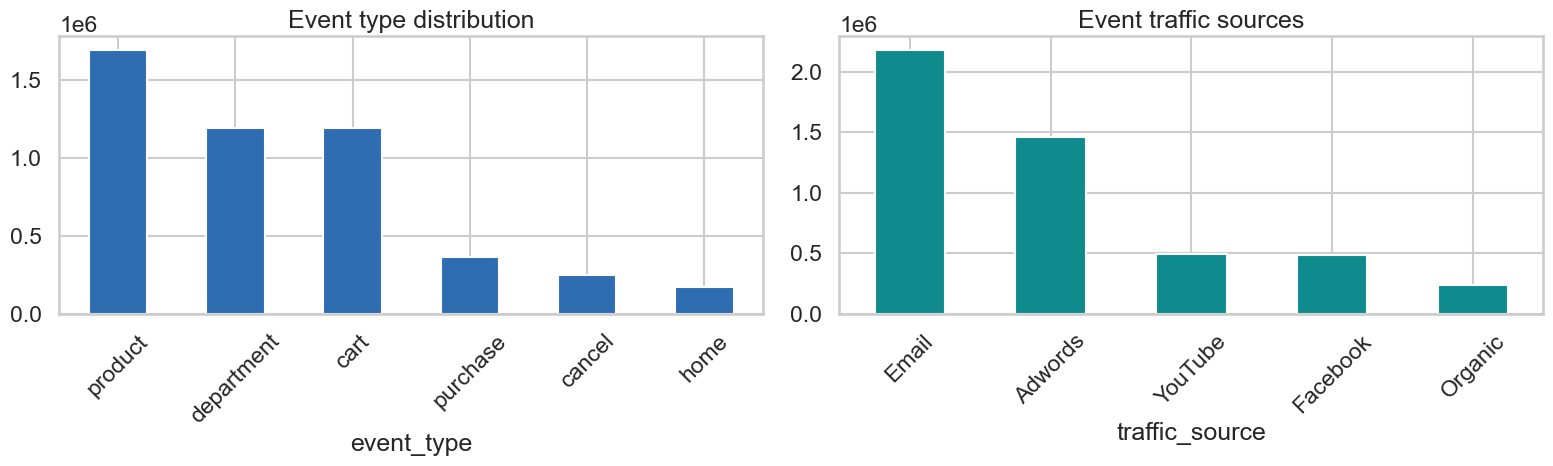

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
events["event_type"].value_counts().head(10).plot(kind="bar", ax=axes[0], color="#2f6db3")
events["traffic_source"].value_counts().head(10).plot(kind="bar", ax=axes[1], color="#0f8b8d")
axes[0].set_title("Event type distribution")
axes[1].set_title("Event traffic sources")
for ax in axes:
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


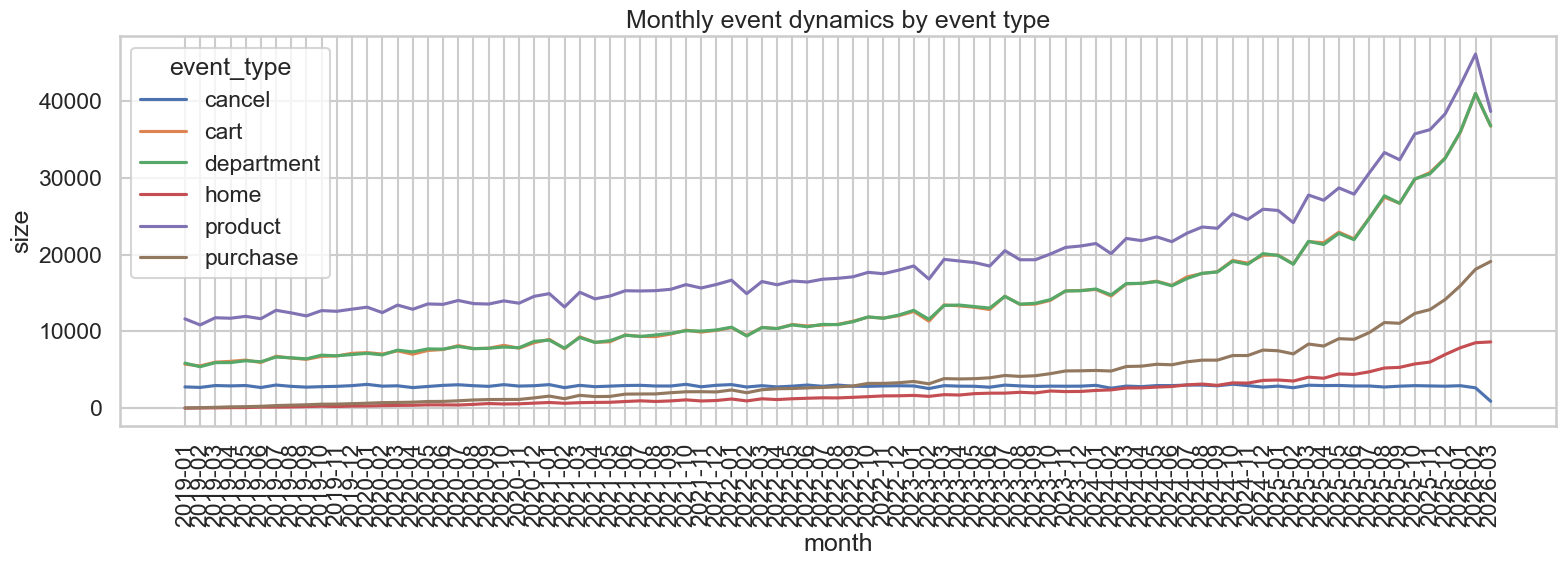

In [20]:
events_monthly = (
    events.assign(month=events["created_at"].dt.tz_localize(None).dt.to_period("M").astype(str))
    .groupby(["month", "event_type"], as_index=False)
    .size()
)

plt.figure(figsize=(16, 6))
sns.lineplot(data=events_monthly, x="month", y="size", hue="event_type")
plt.xticks(rotation=90)
plt.title("Monthly event dynamics by event type")
plt.tight_layout()
plt.show()


## 7. Выводы после первичного анализа

### Категории с повышенным риском возврата

Наиболее проблемные категории по доле возвратов:

- `Women / Jumpsuits & Rompers` около `11.4%`
- `Women / Pants & Capris` около `11.0%`
- `Men / Swim` около `10.7%`
- `Women / Socks & Hosiery` около `10.7%`
- `Men / Suits & Sport Coats` около `10.5%`
- `Women / Sleep & Lounge` около `10.4%`
- `Men / Underwear` около `10.3%`

Бизнес-вывод: такие категории не стоит продвигать слишком агрессивно, особенно клиентам с высоким риском ухода. В будущей системе рекомендаций для них нужен штраф или понижение приоритета.

### Склады и доставка как возможный фактор риска

Самые медленные склады по медианному времени доставки:

- `New Orleans LA` около `2.55` дня
- `Memphis TN` около `2.55` дня
- `Savannah GA` около `2.53` дня
- `Philadelphia PA` около `2.51` дня
- `Port Authority of New York/New Jersey NY/NJ` около `2.50` дня

У части этих складов и доля возвратов немного выше среднего. Это означает, что логистика может быть одним из сигналов риска ухода клиента.

Бизнес-вывод: в таблицу клиентов и в модель ухода нужно включать среднее время до отправки, среднее время доставки, число отмен и долю возвратов.

### Каналы привлечения и качество трафика

По числу заказов лидируют:

- `Search`
- `Organic`
- `Facebook`
- `Email`
- `Display`

По доле сессий, заканчивающихся покупкой, каналы довольно близки:

- `YouTube` около `26.9%`
- `Facebook` около `26.7%`
- `Adwords` около `26.7%`
- `Email` около `26.6%`
- `Organic` около `26.2%`

При этом доля отмен по сессиям тоже высокая почти у всех каналов, примерно `18-18.5%`.

Бизнес-вывод: канал привлечения важен как признак, но не выглядит единственной причиной проблем. Его стоит учитывать вместе с поведением клиента, доставкой и возвратами.

### Поведенческие признаки для прогноза ухода

Из таблицы событий можно использовать следующие признаки:

- число сессий пользователя;
- общее число событий;
- среднее число действий за сессию;
- число просмотров товаров;
- число действий с корзиной;
- число покупок в событиях;
- давность последней активности.

По текущим данным у среднего пользователя около `2.27` сессии, `32.7` событий и `12.5` действий на одну сессию.

Бизнес-вывод: снижение активности, уменьшение числа сессий и слабое взаимодействие с товарами можно использовать как ранние сигналы возможного ухода клиента.

Важно: в `events.csv` примерно у половины событий нет `user_id`, поэтому поведенческие признаки будут неполными и это нужно честно учитывать при построении модели.

### Лояльные и нелояльные клиенты

По данным:

- нелояльных клиентов больше: `64,491`;
- лояльных меньше: `15,530`;
- при этом лояльные клиенты дают очень заметную долю заказов и выручки.

Бизнес-вывод: лояльных клиентов обязательно нужно выделять в отдельную стратегию удержания. Потеря такого клиента для бизнеса дороже, чем потеря случайного покупателя.

### Главный итог EDA

После первичного анализа видно, что самые важные направления для сильного решения такие:

- возвраты по категориям;
- скорость и качество доставки;
- активность клиента в событиях;
- разделение клиентов по ценности и лояльности.

Следующий шаг после EDA: собрать таблицу по клиентам, определить правило ухода клиента и подготовить признаки для модели прогноза ухода и рекомендательной системы.